In [1]:
import os, sys
from contextlib import contextmanager

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import jaxmapse


In [2]:
#--- Cosmology (flat LCDM / w0waCDM for HMCode) ---
cosmo = {
    "ln10As":  3.044,
    "ns":      0.9649,
    "H0":      67.36,
    "omega_b": 0.02237,
    "omega_c": 0.12,
    "Mnu":     0.06,
    "w0":     -1.0,
    "wa":      0.0,
}

params = jnp.array([
    cosmo["ln10As"], cosmo["ns"], cosmo["H0"],
    cosmo["omega_b"], cosmo["omega_c"], cosmo["Mnu"],
    cosmo["w0"], cosmo["wa"],
])

z_eval = jnp.array([0.0, 1.0, 2.0, 3.0, 4.0])

In [3]:
trained = jaxmapse.load_trained_emulators()[jaxmapse.DEFAULT_EMULATOR_ARTIFACT]
pmm = trained["pmm"]
pcb = trained["pcb"]
k = np.asarray(pmm.k_grid)
print("k grid:", k.shape, k.min(), k.max())


k grid: (300,) 4.9999999999999996e-06 100.0


In [4]:
h = cosmo["H0"] / 100.0
jax_cosmo = jaxmapse.w0waCDMCosmology(
    ln10As=cosmo["ln10As"],
    ns=cosmo["ns"],
    h=h,
    omega_b=cosmo["omega_b"],
    omega_c=cosmo["omega_c"],
    m_nu=cosmo["Mnu"],
    w0=cosmo["w0"],
    wa=cosmo["wa"],
)
D_eval = jnp.asarray(jax_cosmo.D_z(z_eval))
print("D(z):", np.asarray(D_eval))


D(z): [0.77129877 0.46860294 0.32251206 0.24406407 0.19596748]


In [5]:
Pmm_emu = np.asarray(pmm(params, z_eval, D_eval))
Pcb_emu = np.asarray(pcb(params, z_eval, D_eval))
print("Pmm_emu:", Pmm_emu.shape, " Pcb_emu:", Pcb_emu.shape)


Pmm_emu: (5, 300)  Pcb_emu: (5, 300)


## CLASS reference

In [6]:
def class_params(cosmo, z_max, k_max, nonlinear=True):
    p = {
        "output": "mPk",
        "P_k_max_1/Mpc": float(k_max),
        "z_max_pk": float(z_max),
        "h": cosmo["H0"] / 100.0,
        "omega_b": cosmo["omega_b"],
        "omega_cdm": cosmo["omega_c"],
        "N_ur": 2.0328,
        "N_ncdm": 1,
        "m_ncdm": cosmo["Mnu"],
        "tau_reio": 0.0544,
        "A_s": float(np.exp(cosmo["ln10As"]) * 1e-10),
        "n_s": cosmo["ns"],
        "w0_fld": cosmo["w0"],
        "wa_fld": cosmo["wa"],
        "Omega_Lambda": 0.0,
        "fluid_equation_of_state": "CLP",
        "use_ppf": "yes",
    }
    if nonlinear:
        p["non linear"] = "hmcode"
    return p

def make_class(cosmo, z_eval, k_max, nonlinear=True):
    c = Class()
    c.set(class_params(cosmo, z_max=float(np.max(z_eval)) + 0.5, k_max=float(k_max) * 1.05, nonlinear=nonlinear))
    c.compute()
    return c

def class_power_on_grid(results, k_query):
    Pmm_lin = np.array([[results.pk_lin(float(kk), float(zz)) for kk in k_query] for zz in z_eval])
    Pcb_lin = np.array([[results.pk_cb_lin(float(kk), float(zz)) for kk in k_query] for zz in z_eval])
    Pmm_nl  = np.array([[results.pk(float(kk), float(zz)) for kk in k_query] for zz in z_eval])
    return Pmm_lin, Pcb_lin, Pmm_nl

def class_background_for_hmcode(cosmo, z_eval):
    bg = cosmo.get_background()
    z_table = np.asarray(bg["z"])
    order = np.argsort(z_table)
    z_sorted = z_table[order]
    omega_m_sorted = np.asarray(bg["Omega_m(z)"])[order]
    rho_crit = np.asarray(bg["(.)rho_crit"])
    rho_de = np.zeros_like(rho_crit)
    if "(.)rho_fld" in bg:
        rho_de = rho_de + np.asarray(bg["(.)rho_fld"])
    if "(.)rho_lambda" in bg:
        rho_de = rho_de + np.asarray(bg["(.)rho_lambda"])
    omega_v_sorted = (rho_de / rho_crit)[order]
    omega_m_z = np.interp(z_eval, z_sorted, omega_m_sorted)
    omega_v_z = np.interp(z_eval, z_sorted, omega_v_sorted)
    return omega_m_z, omega_v_z


In [7]:
# jaxmapse linear emulators: shape is (len(z), len(k_support)).
Pmm_emu = np.asarray(pmm(params, z_eval, D_eval))
Pcb_emu = np.asarray(pcb(params, z_eval, D_eval))

# CLASS reference: HMCode2020 for the nonlinear spectrum.
k_max = float(k.max())
class_cosmo = make_class(cosmo, np.asarray(z_eval), k_max, nonlinear=True)
Pmm_class_lin, Pcb_class_lin, Pmm_class_hmcode = class_power_on_grid(class_cosmo, k)
omega_m_class_z, omega_v_class_z = class_background_for_hmcode(class_cosmo, np.asarray(z_eval))

# HMCode cosmology struct for jaxmapse.
omega_nu = (cosmo["Mnu"] / 93.14) / h**2
omega_m = (cosmo["omega_b"] + cosmo["omega_c"]) / h**2 + omega_nu
omega_b = cosmo["omega_b"] / h**2
hmcode_cosmo = jaxmapse.HMCodeCosmology(
    Omega_m=omega_m, Omega_b=omega_b, h=h,
    n_s=cosmo["ns"], sigma_8=0.8109118,
    w0=cosmo["w0"], wa=cosmo["wa"],
    Omega_nu=omega_nu, Omega_k=0.0,
)

# jaxmapse HMCode nonlinear Pmm on the emulator k-grid.
Pmm_jax_hmcode = np.asarray(jaxmapse.hmcode_Pmm(
    hmcode_cosmo,
    z_eval,
    jnp.asarray(k),
    jnp.asarray(Pmm_emu),
    pk_cb_z=jnp.asarray(Pcb_emu),
    accuracy=1.0,
))

print("Pmm_emu:", Pmm_emu.shape)
print("Pcb_emu:", Pcb_emu.shape)
print("Pmm_jax_hmcode:", Pmm_jax_hmcode.shape)
print("Pmm_class_hmcode:", Pmm_class_hmcode.shape)


SYNC_UPSTREAM: h=6.736000e-01 G=6.674280e-11 Tcmb=2.725500e+00 rho_crit=1.259252e+11
SYNC_BG: z=0.000000e+00 Om=3.151917e-01 rhotot=5.048505e-08 rhocrit=5.048505e-08 H=2.246888e-04
DEBUG_HMCODE: z=0, dc=1.675593e+00, dv=3.016285e+02, fnu=4.504460e-03, dv_x=7.879342e-01, dv_y=9.329317e-01, Omn=3.152161e-01
DEBUG_HMCODE: index_mass=0, M=1.484561e+03, nu=1.494307e-01, sig=1.121318e+01, sigf=1.334738e+01
DEBUG_HMCODE: index_mass=50, M=1.296506e+06, nu=2.096265e-01, sig=7.993232e+00, sigf=1.019632e+01
DEBUG_HMCODE: index_mass=100, M=1.132272e+09, nu=3.467274e-01, sig=4.832595e+00, sigf=6.945570e+00
DEBUG_HMCODE: index_mass=150, M=9.888430e+11, nu=7.421697e-01, sig=2.257695e+00, sigf=3.927958e+00
DEBUG_HMCODE: index_mass=200, M=8.635824e+14, nu=2.711811e+00, sig=6.178871e-01, sigf=1.614580e+00
DEBUG_HMCODE: index_mass=250, M=7.541891e+17, nu=2.925808e+01, sig=5.726940e-02, sigf=3.340465e-01
DEBUG_HMCODE: z=0, r_nl=3.471122e+00, neff=-2.005468e+00, dlnsigdlnR=-9.945322e-01
DEBUG_HMCODE: z=0, 

In [8]:
def relerr(model, reference):
    return model / reference - 1.0

def percent_relerr(model, reference):
    return 100.0 * relerr(model, reference)

summary_mask = (k >= 1e-4) & (k <= 10.0)
for name, err_pct in {
    'linear Pmm emulator vs CLASS': percent_relerr(Pmm_emu, Pmm_class_lin),
    'linear Pcb emulator vs CLASS': percent_relerr(Pcb_emu, Pcb_class_lin),
    'HMCode(emulated Pmm+Pcb) vs CLASS HMCode2020': percent_relerr(Pmm_jax_hmcode, Pmm_class_hmcode),
}.items():
    e = err_pct[:, summary_mask]
    print(name)
    print(f'  mean |rel| = {np.mean(np.abs(e)):.4e}%')
    print(f'  rms  rel   = {np.sqrt(np.mean(e**2)):.4e}%')
    print(f'  max  |rel| = {np.max(np.abs(e)):.4e}%')


linear Pmm emulator vs CLASS
  mean |rel| = 3.1597e-02%
  rms  rel   = 4.6551e-02%
  max  |rel| = 1.9032e-01%
linear Pcb emulator vs CLASS
  mean |rel| = 3.0889e-02%
  rms  rel   = 4.0884e-02%
  max  |rel| = 1.4612e-01%
HMCode(emulated Pmm+Pcb) vs CLASS HMCode2020
  mean |rel| = 1.6208e+00%
  rms  rel   = 3.4925e+00%
  max  |rel| = 3.3318e+01%


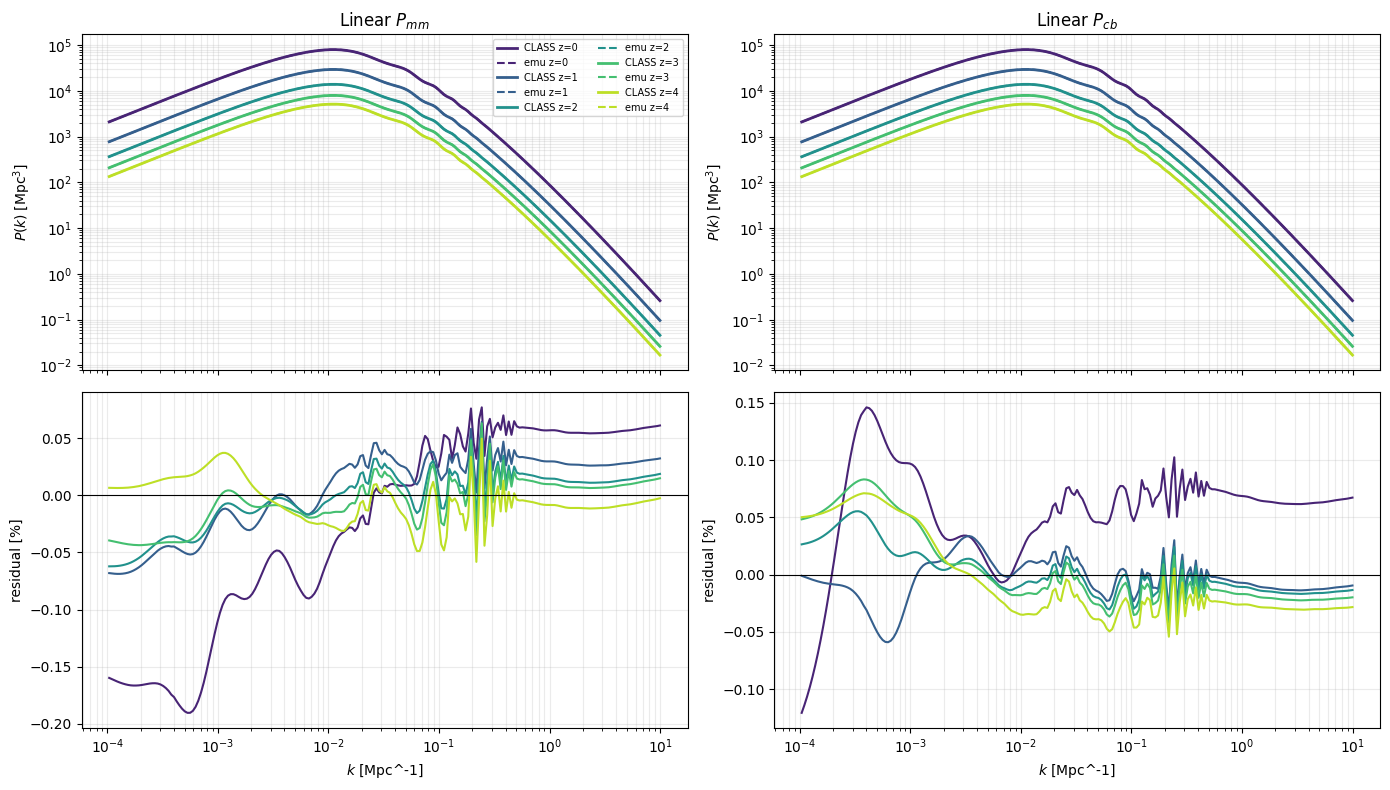

In [9]:
mask = (k >= 1e-4) & (k <= 10.0)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(z_eval)))
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")
for col, (title, emu_pk, class_pk) in enumerate([
    (r"Linear $P_{mm}$", Pmm_emu, Pmm_class_lin),
    (r"Linear $P_{cb}$", Pcb_emu, Pcb_class_lin),
]):
    ax_top = axes[0, col]
    ax_res = axes[1, col]
    for iz, (zz, color) in enumerate(zip(z_eval, colors)):
        ax_top.loglog(k[mask], class_pk[iz, mask], color=color, lw=2, label=f"CLASS z={zz:g}")
        ax_top.loglog(k[mask], emu_pk[iz, mask], color=color, ls="--", lw=1.5, label=f"emu z={zz:g}")
        rel = 100.0 * (emu_pk / class_pk - 1.0)
        ax_res.semilogx(k[mask], rel[iz, mask], color=color, lw=1.5)
    ax_top.set_title(title)
    ax_top.set_ylabel(r"$P(k)\;[\mathrm{Mpc}^3]$")
    ax_top.grid(True, which="both", alpha=0.25)
    ax_res.axhline(0.0, color="k", lw=0.8)
    ax_res.set_xlabel("$k$ [Mpc^-1]")
    ax_res.set_ylabel("residual [%]")
    ax_res.grid(True, which="both", alpha=0.25)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()


## HMCode2020 comparison

In [10]:
# Baseline jaxmapse HMCode with emulated linear spectra.
Pmm_jax_hmcode = np.asarray(jaxmapse.hmcode_Pmm(
    hmcode_cosmo,
    z_eval,
    jnp.asarray(k),
    jnp.asarray(Pmm_emu),
    pk_cb_z=jnp.asarray(Pcb_emu),
    accuracy=1.0,
))

# Diagnostic baseline: CLASS linear spectra fed into the same jaxmapse HMCode machinery.
Pmm_jax_hmcode_class_lin = np.asarray(jaxmapse.hmcode_Pmm(
    hmcode_cosmo,
    z_eval,
    jnp.asarray(k),
    jnp.asarray(Pmm_class_lin),
    pk_cb_z=jnp.asarray(Pcb_class_lin),
    accuracy=1.0,
))

print("HMCode emu:", Pmm_jax_hmcode.shape)
print("HMCode CLASS-linear:", Pmm_jax_hmcode_class_lin.shape)


HMCode emu: (5, 300)
HMCode CLASS-linear: (5, 300)


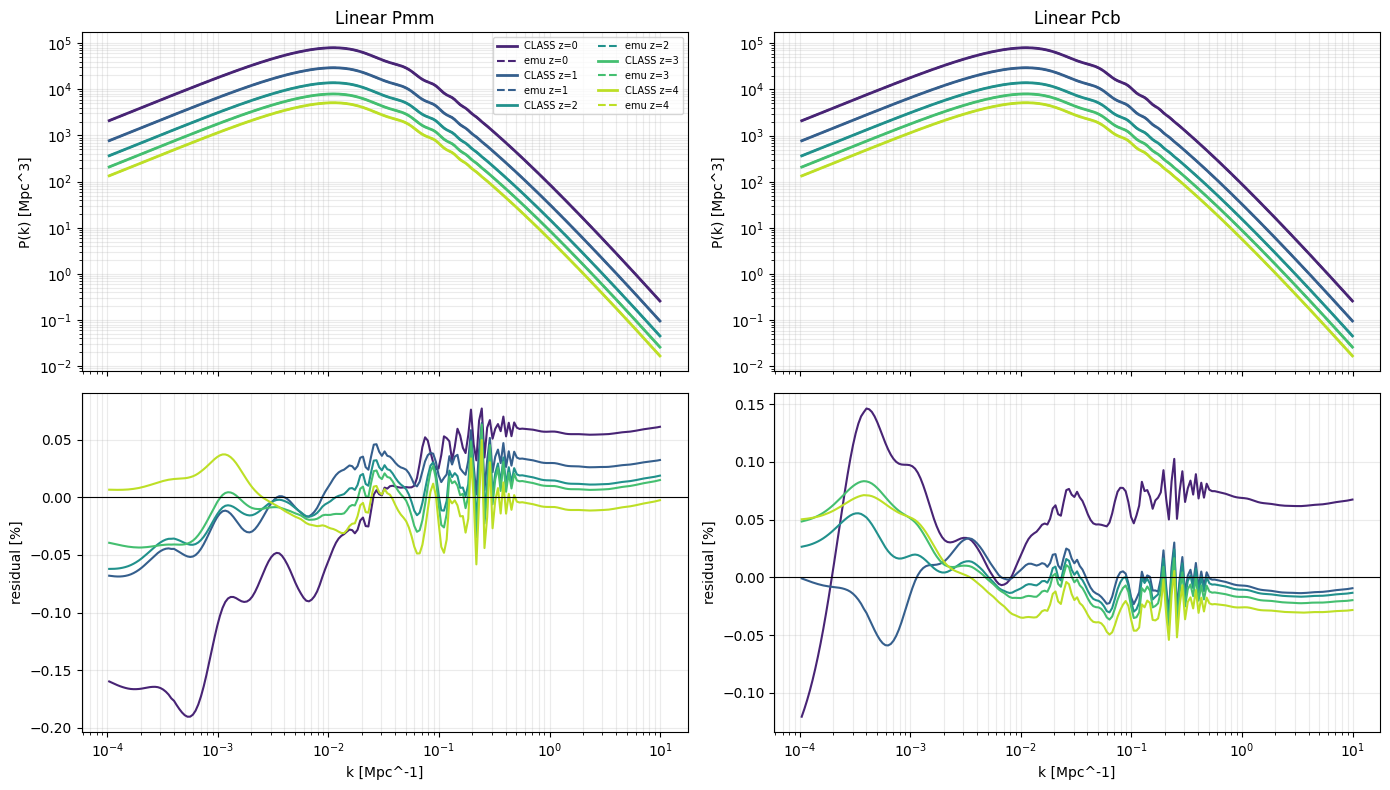

In [11]:
mask = (k >= 1e-4) & (k <= 10.0)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(z_eval)))
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
for col, (title, emu_pk, class_pk) in enumerate([
    ('Linear Pmm', Pmm_emu, Pmm_class_lin),
    ('Linear Pcb', Pcb_emu, Pcb_class_lin),
]):
    ax_top = axes[0, col]
    ax_res = axes[1, col]
    for iz, (zz, color) in enumerate(zip(z_eval, colors)):
        ax_top.loglog(k[mask], class_pk[iz, mask], color=color, lw=2, label=f'CLASS z={zz:g}')
        ax_top.loglog(k[mask], emu_pk[iz, mask], color=color, ls='--', lw=1.5, label=f'emu z={zz:g}')
        rel = 100.0 * (emu_pk / class_pk - 1.0)
        ax_res.semilogx(k[mask], rel[iz, mask], color=color, lw=1.5)
    ax_top.set_title(title)
    ax_top.set_ylabel('P(k) [Mpc^3]')
    ax_top.grid(True, which='both', alpha=0.25)
    ax_res.axhline(0.0, color='k', lw=0.8)
    ax_res.set_xlabel('k [Mpc^-1]')
    ax_res.set_ylabel('residual [%]')
    ax_res.grid(True, which='both', alpha=0.25)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()


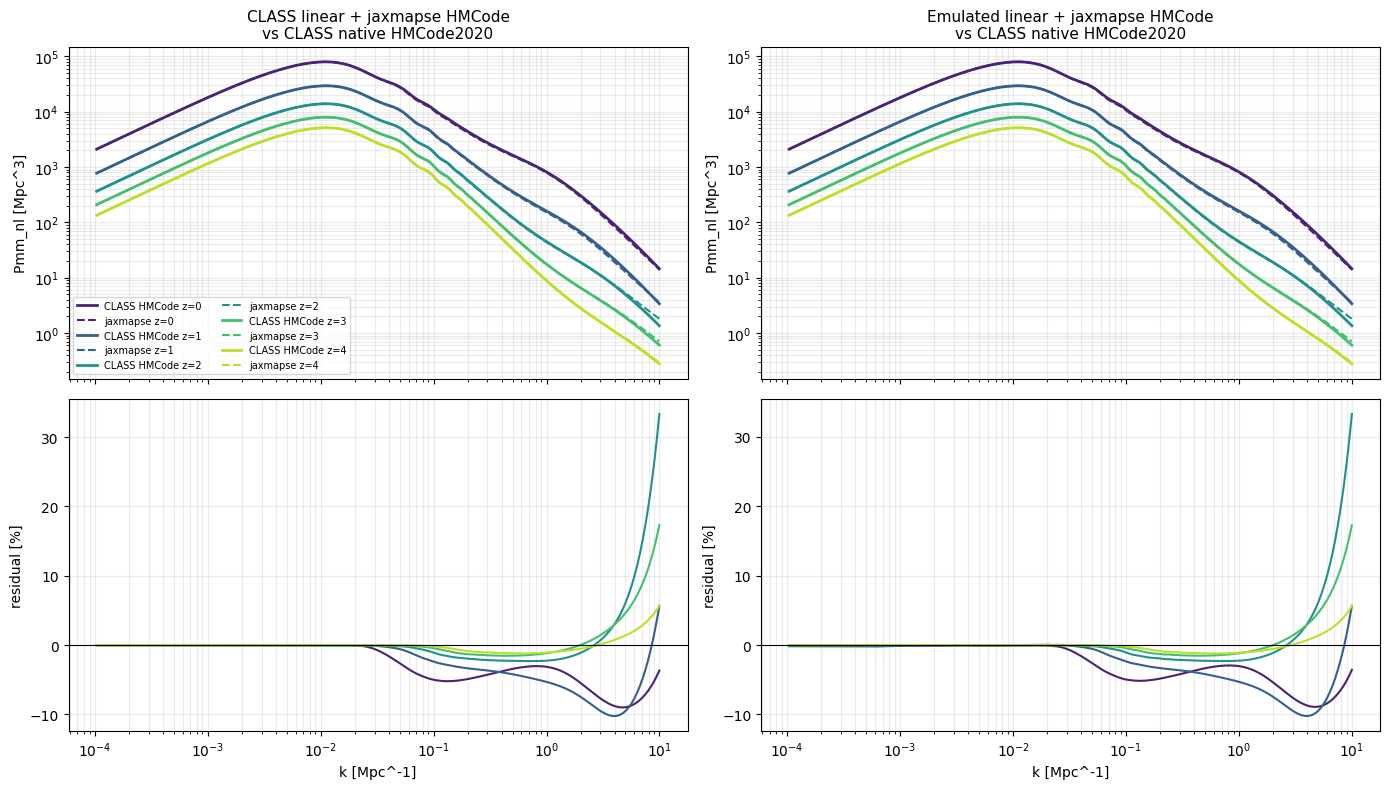

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
panels = [
    ('CLASS linear + jaxmapse HMCode\nvs CLASS native HMCode2020', Pmm_jax_hmcode_class_lin, Pmm_class_hmcode),
    ('Emulated linear + jaxmapse HMCode\nvs CLASS native HMCode2020', Pmm_jax_hmcode, Pmm_class_hmcode),
]
for col, (title, model, reference) in enumerate(panels):
    ax_top = axes[0, col]
    ax_res = axes[1, col]
    for iz, (zz, color) in enumerate(zip(z_eval, colors)):
        ax_top.loglog(k[mask], reference[iz, mask], color=color, lw=2, label=f'CLASS HMCode z={zz:g}')
        ax_top.loglog(k[mask], model[iz, mask], color=color, ls='--', lw=1.5, label=f'jaxmapse z={zz:g}')
        rel = 100.0 * (model / reference - 1.0)
        ax_res.semilogx(k[mask], rel[iz, mask], color=color, lw=1.5)
    ax_top.set_title(title, fontsize=11)
    ax_top.set_ylabel('Pmm_nl [Mpc^3]')
    ax_top.grid(True, which='both', alpha=0.25)
    ax_res.axhline(0.0, color='k', lw=0.8)
    ax_res.set_xlabel('k [Mpc^-1]')
    ax_res.set_ylabel('residual [%]')
    ax_res.grid(True, which='both', alpha=0.25)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()
